In [1]:
!pip install numpy pandas matplotlib scipy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use('default')

In [3]:
PATH = "../Datasets/UCI Dynamic Gas Mixtures"

In [4]:
ethylene_co = pd.read_csv(PATH + "/ethylene_CO.txt", sep=r'\s+', skiprows=1, names=['Time', 'Methane', 'Ethylene'] + [f's{i}' for i in range(1, 17)])

In [5]:
ethylene_co

,Time,Methane,Ethylene,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16
0,0.00,0.0,0.0,-50.85,-1.95,-41.82,1.30,-4.07,-28.73,-13.49,-3.25,55139.95,50669.50,9626.26,9762.62,24544.02,21420.68,7650.61,6928.42
1,0.01,0.0,0.0,-49.40,-5.53,-42.78,0.49,3.58,-34.55,-9.59,5.37,54395.77,50046.91,9433.20,9591.21,24137.13,20930.33,7498.79,6800.66
2,0.01,0.0,0.0,-40.04,-16.09,-27.59,0.00,-7.16,-42.14,-12.52,-5.86,53960.02,49299.30,9324.40,9449.81,23628.90,20504.94,7369.67,6697.47
3,0.03,0.0,0.0,-47.14,-10.57,-32.28,4.40,-11.22,-37.94,-7.16,-1.14,53047.71,48907.00,9170.64,9305.58,23101.66,20101.42,7285.13,6578.52
4,0.04,0.0,0.0,-33.58,-20.79,-33.25,6.03,3.42,-34.22,-14.46,8.31,52700.28,48330.96,9073.64,9163.47,22689.54,19694.07,7156.74,6468.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4208256,42087.51,0.0,0.0,1127.81,105.93,2117.39,2247.58,1207.59,1646.73,2089.97,2262.98,1061.70,1070.47,2570.33,2073.57,709.06,775.36,2513.75,1848.65
4208257,42087.52,0.0,0.0,1140.73,96.46,2105.93,2253.69,1216.39,1624.47,2073.57,2246.61,1063.89,1075.26,2580.88,2083.78,698.24,768.93,2511.20,1843.63
4208258,42087.53,0.0,0.0,1123.99,107.92,2111.18,2245.63,1215.36,1628.44,2085.45,2271.80,1059.31,1063.49,2583.20,2090.20,709.62,775.73,2510.18,1841.80
4208259,42087.54,0.0,0.0,1131.44,111.08,2114.76,2249.54,1197.99,1612.17,2078.32,2272.29,1063.69,1066.08,2578.56,2100.92,716.72,779.14,2508.91,1851.17


In [6]:
# запустить это если без нормализации
normalized = False

In [5]:
# апустить это, если с нормализацией
normalize_columns = ['Methane', 'Ethylene'] + [f's{i}' for i in range(1, 17)]
def min_max_scaler(normalize_columns, ds):
    for col in normalize_columns:
        ds[col] = (ds[col] - ds[col].min()) / (ds[col].max() - ds[col].min())
min_max_scaler(normalize_columns, ethylene_co)
normalized = True

In [7]:
def mono_exp(x, m, t, b):
    return m * np.exp(-t * x) + b

In [59]:
from_indexes = [52500, 52500, 52500, 53000, 52500, 52500, 52500, 52500, 52500, 52500, 52500, 52500, 52500, 52500, 52500, 52500, 52500, 52500]
to_indexes = [61200, 61200, 62000, 62000, 61200, 61200, 61200, 61200, 61200, 61200, 61200, 61200, 61200, 61200, 61200, 61200, 61200, 61200]

In [60]:
len(to_indexes)

18

In [81]:
names = ['TGS2602', 'TGS2602', 'TGS2600', 'TGS2600', 'TGS2610', 'TGS2610', 'TGS2620', 'TGS2620', 'TGS2602', 'TGS2602', 'TGS2600', 'TGS2600', 'TGS2610', 'TGS2610', 'TGS2620', 'TGS2620']

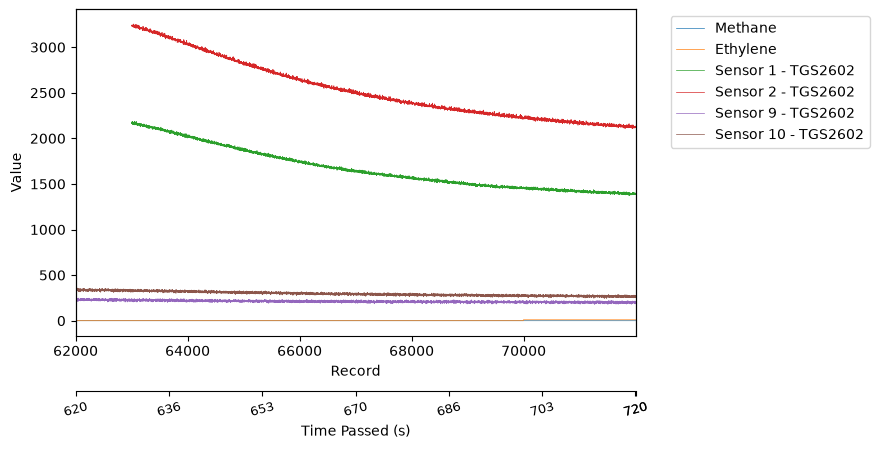

In [83]:
x = ethylene_co.index.to_list()
label = "Record"

line_width = 0.5
plt.plot(x[from_indexes[0] : to_indexes[0]], ethylene_co['Methane'].iloc[from_indexes[0] : to_indexes[0]], label="Methane", linewidth=line_width)
plt.plot(x[from_indexes[1] : to_indexes[1]], ethylene_co['Ethylene'].iloc[from_indexes[1] : to_indexes[1]], label="Ethylene", linewidth=line_width)
for i in range(1, 17):
    if not names[i-1] == "TGS2602":
        continue
    plt.plot(x[from_indexes[1 + i] : to_indexes[1 + i]], ethylene_co[f's{i}'].iloc[from_indexes[1 + i] : to_indexes[1 + i]], label=f"Sensor {i} - {names[i-1]}", linewidth=line_width)
plt.margins(x=0)
plt.xlabel(label)
plt.ylabel("Value")
plt.title("")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

# НАЧАЛО БЛОКА: В этом блоке код написан нейросетью для отображения оси времени
ax1 = plt.gca()
ax2 = ax1.twiny()

ax2.spines['bottom'].set_position(('outward', 40))
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')

x_slice = x[min(from_indexes) : max(to_indexes)]
time_slice = ethylene_co['Time'].iloc[min(from_indexes) : max(to_indexes)].to_list()

n_ticks = 6
step = max(1, len(time_slice) // n_ticks)
tick_indices = list(range(0, len(time_slice), step))
if (len(time_slice) - 1) not in tick_indices:
    tick_indices.append(len(time_slice) - 1)

tick_x_values = [x_slice[i] for i in tick_indices]
tick_labels = [int(time_slice[i]) for i in tick_indices]

ax2.set_xticks(tick_x_values)
ax2.set_xticklabels(tick_labels, rotation=15, fontsize=9)
ax2.set_xlabel("Time Passed (s)")

ax2.set_xlim(ax1.get_xlim())
# КОНЕЦ БЛОКА

plt.subplots_adjust(right=1, bottom=0.2)
plt.show()

R² = 0.9935536138292456
t = 0.00019648730507825928


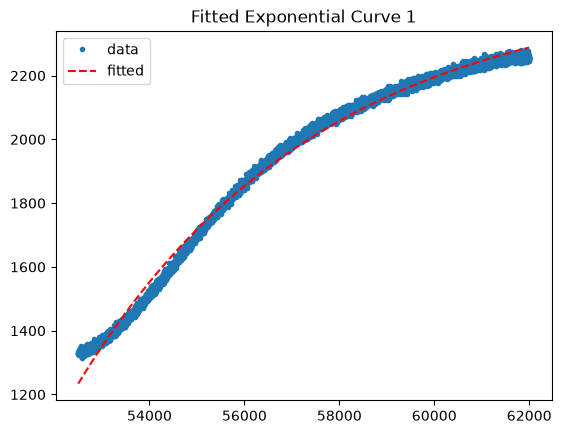

R² = 0.996361628080882
t = 0.00019890362235120248


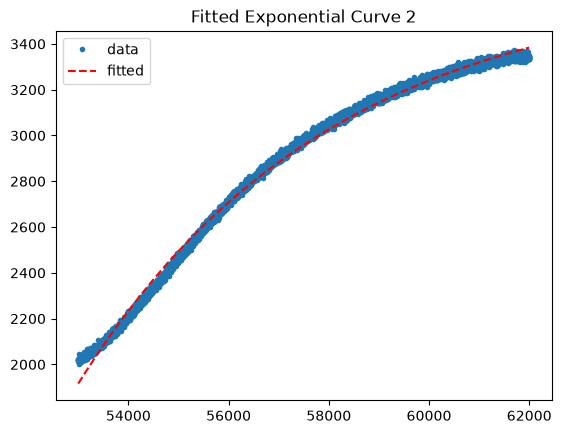

R² = 0.997374384869331
t = 0.0006426382030122979


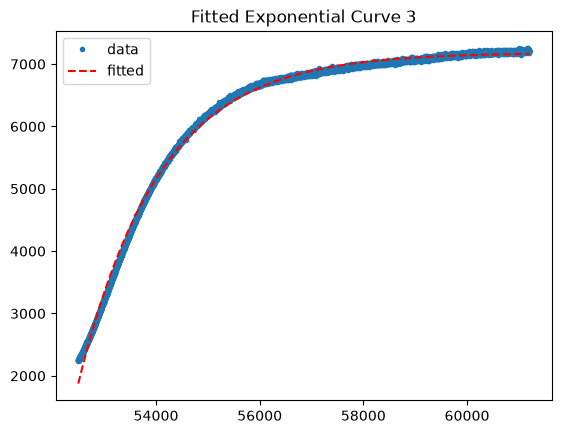

R² = 0.9974022428743262
t = 0.0006316841631987134


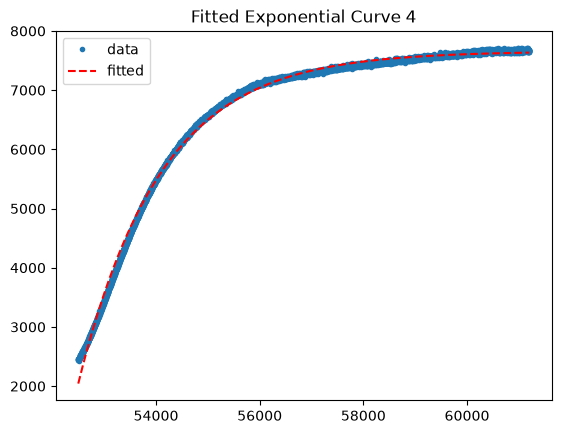

R² = 0.9974301367082347
t = 0.0008144117714876807


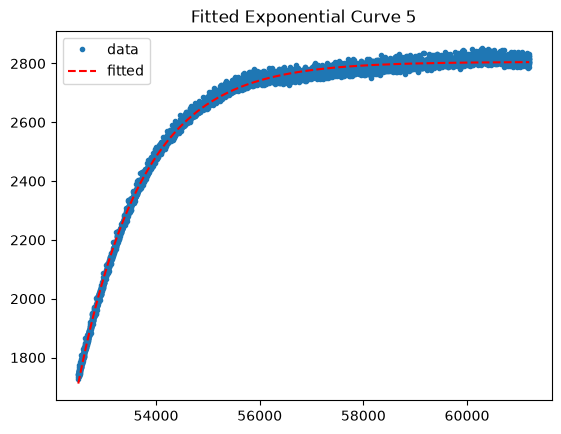

R² = 0.9958945552175943
t = 0.0009386913845182802


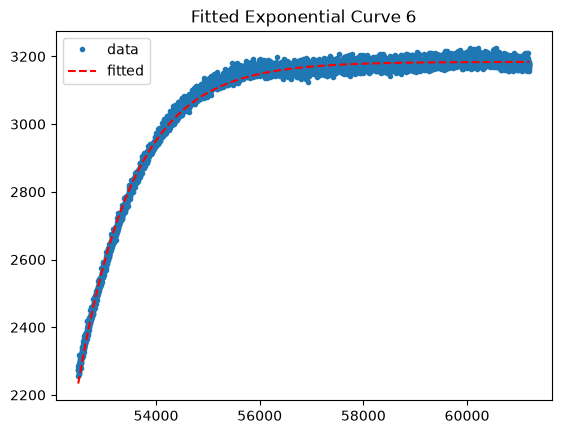

R² = 0.9973906806098523
t = 0.0008697125167402955


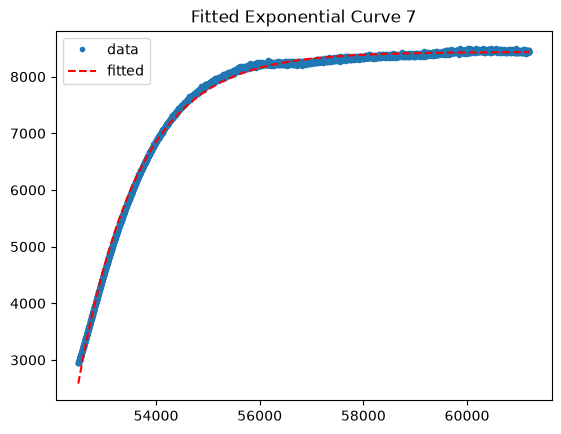

R² = 0.9980826302455912
t = 0.0008390460223391656


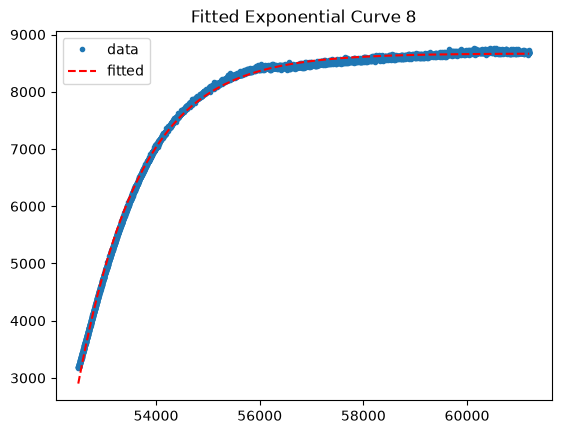

R² = 0.265825125942312
t = 0.00040835617505165884


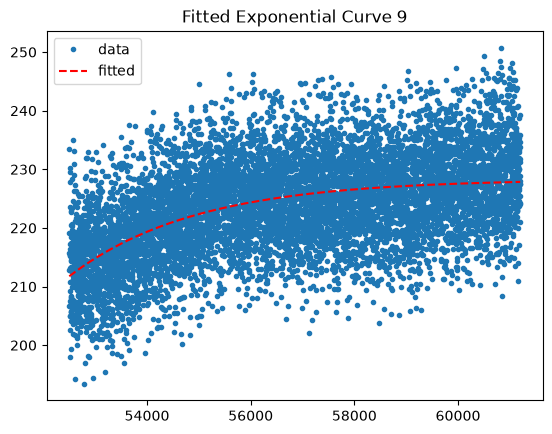

R² = 0.8769447683419712
t = 0.00015017195309785354


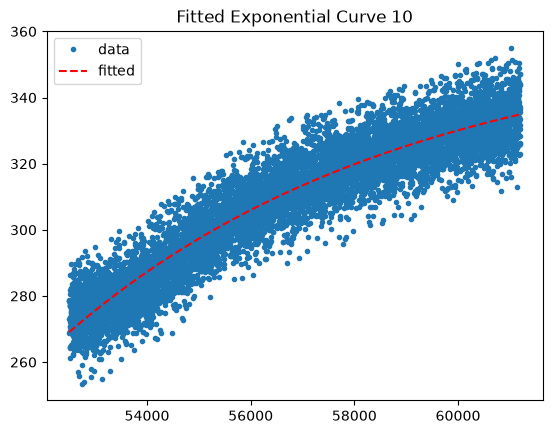

R² = 0.9978010919071559
t = 0.0005964128982486722


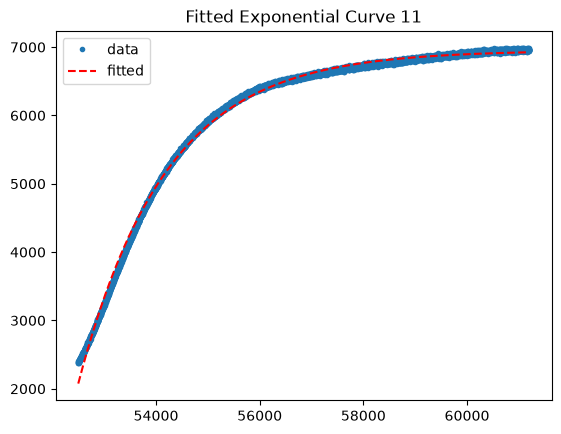

R² = 0.9983577480103099
t = 0.0006385625604248536


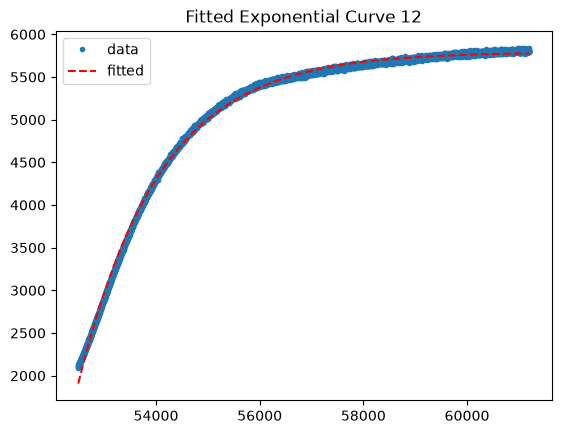

R² = 0.9796521766281059
t = 0.0008812965508979903


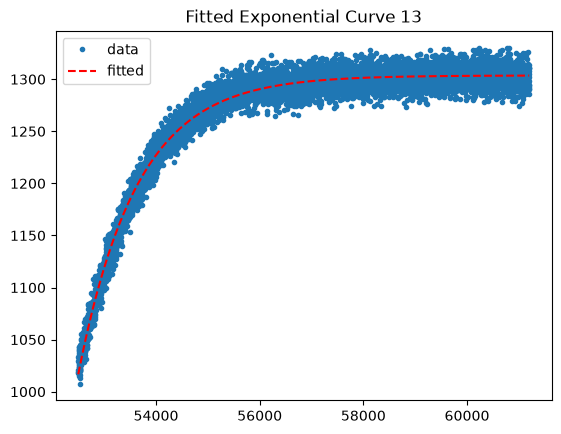

R² = 0.9857432728084169
t = 0.0007834408605876148


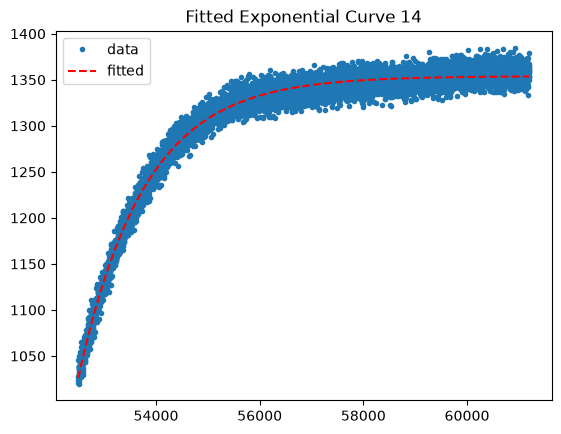

R² = 0.9984806486723815
t = 0.0007514354173638783


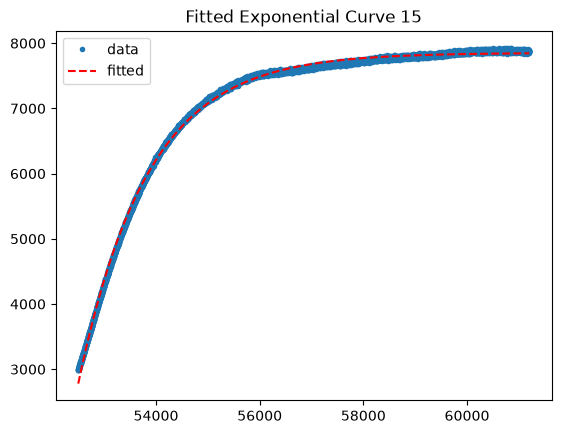

R² = 0.9979347951197824
t = 0.0008388304380632057


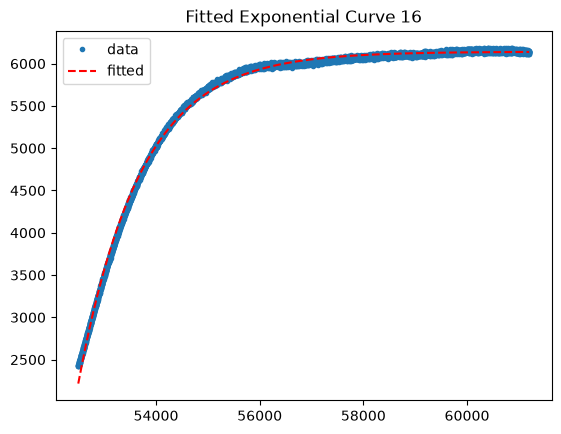

In [62]:
fitting_results = []

for i in range(3, 19):
    sensor_number = i - 2

    from_index = from_indexes[sensor_number + 1]
    to_index = to_indexes[sensor_number + 1]

    xs = ethylene_co.index.to_list()[from_index:to_index]
    xs = np.array(xs)

    ys = ethylene_co.iloc[from_index:to_index, i]
    ys = np.array(ys)

    # сохраняем длину участка, но НЕ нормализуем по ней
    segment_length = to_index - from_index

    xs_shifted = xs - xs[0]

    start_y = ys[0]
    end_y = ys[-1]

    # Плато теперь в конце
    # y(∞) = b, поэтому b примерно равно конечному значению
    estimated_b = end_y

    # y(0) = m + b
    estimated_m = start_y - end_y

    # t должно быть положительным, чтобы экспонента затухала к плато
    estimated_t = 0.001

    p0 = (estimated_m, estimated_t, estimated_b)

    params, cv = scipy.optimize.curve_fit(
        mono_exp,
        xs_shifted,
        ys,
        p0=p0,
        maxfev=20000
    )

    m, t, b = params

    fitted_ys = mono_exp(xs_shifted, m, t, b)

    squaredDiffs = np.square(ys - fitted_ys)
    squaredDiffsFromMean = np.square(ys - np.mean(ys))
    rSquared = 1 - np.sum(squaredDiffs) / np.sum(squaredDiffsFromMean)

    print(f"R² = {rSquared}")
    print(f"t = {t}")

    fitting_results.append({
        "sensor_number": sensor_number,
        "segment_length": segment_length,
        "m": m,
        "t": t,
        "b": b,
        "r2": rSquared
    })

    plt.plot(xs, ys, '.', label="data")
    plt.plot(xs, fitted_ys, '--', label="fitted", color="red")
    plt.title(f"Fitted Exponential Curve {sensor_number}")
    plt.legend()
    plt.savefig(
        f"exponential_fitting_graphs/"
        f'{"normalized/" if normalized else ""}'
        f"exponential_fitting_graph_sensor{sensor_number}.png",
        dpi=300
    )
    plt.show()

df_results = pd.DataFrame(fitting_results)

df_results.to_csv(
    f'fitting_parameters_results{"_normalized" if normalized else ""}.csv',
    index=False
)

In [77]:
from_indexes = [62000, 62000, 63000, 63000, 62000, 62000, 62000, 62000, 62000, 62000, 62000, 62000, 62000, 62000, 62000, 62000, 62000, 62000]
to_indexes = [72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000, 72000]

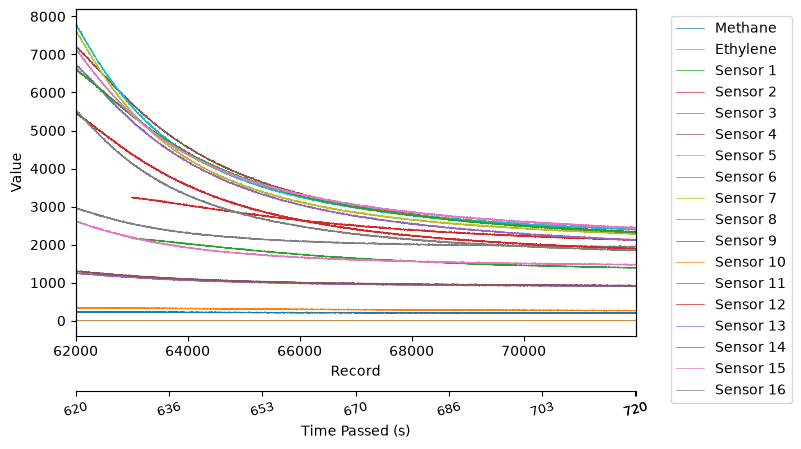

In [78]:
x = ethylene_co.index.to_list()
label = "Record"

line_width = 0.5

# Methane
plt.plot(
    x[from_indexes[0]:to_indexes[0]],
    ethylene_co['Methane'].iloc[from_indexes[0]:to_indexes[0]],
    label="Methane",
    linewidth=line_width
)

# Ethylene
plt.plot(
    x[from_indexes[1]:to_indexes[1]],
    ethylene_co['Ethylene'].iloc[from_indexes[1]:to_indexes[1]],
    label="Ethylene",
    linewidth=line_width
)

# Sensors 1–16
for i in range(1, 17):
    plt.plot(
        x[from_indexes[i + 1]:to_indexes[i + 1]],
        ethylene_co[f's{i}'].iloc[from_indexes[i + 1]:to_indexes[i + 1]],
        label=f"Sensor {i}",
        linewidth=line_width
    )

plt.margins(x=0)
plt.xlabel(label)
plt.ylabel("Value")
plt.title("")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)


# НАЧАЛО БЛОКА: отображение оси времени

ax1 = plt.gca()
ax2 = ax1.twiny()

ax2.spines['bottom'].set_position(('outward', 40))
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')

# Для общей временной оси берем полный диапазон,
# охватывающий все индивидуальные участки
min_index = min(from_indexes)
max_index = max(to_indexes)

x_slice = x[min_index:max_index]
time_slice = ethylene_co['Time'].iloc[min_index:max_index].to_list()

n_ticks = 6
step = max(1, len(time_slice) // n_ticks)

tick_indices = list(range(0, len(time_slice), step))

if (len(time_slice) - 1) not in tick_indices:
    tick_indices.append(len(time_slice) - 1)

tick_x_values = [x_slice[i] for i in tick_indices]
tick_labels = [int(time_slice[i]) for i in tick_indices]

ax2.set_xticks(tick_x_values)
ax2.set_xticklabels(tick_labels, rotation=15, fontsize=9)
ax2.set_xlabel("Time Passed (s)")

ax2.set_xlim(ax1.get_xlim())

# КОНЕЦ БЛОКА

plt.subplots_adjust(right=1, bottom=0.2)
plt.show()

Sensor 1
from_index = 63000, to_index = 72000
R² = 0.9982210365200577
t = 0.00021886408456335438


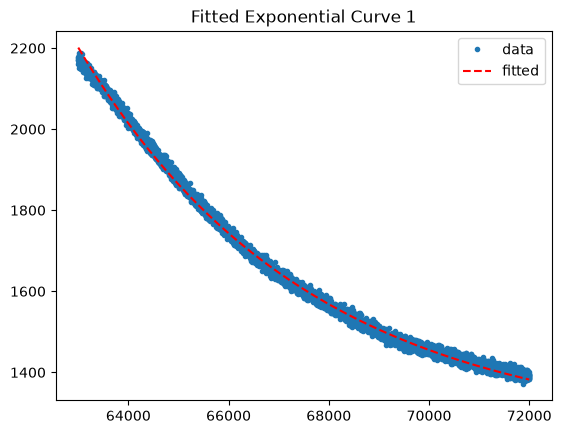

Sensor 2
from_index = 63000, to_index = 72000
R² = 0.9987658945505484
t = 0.00020631997054127606


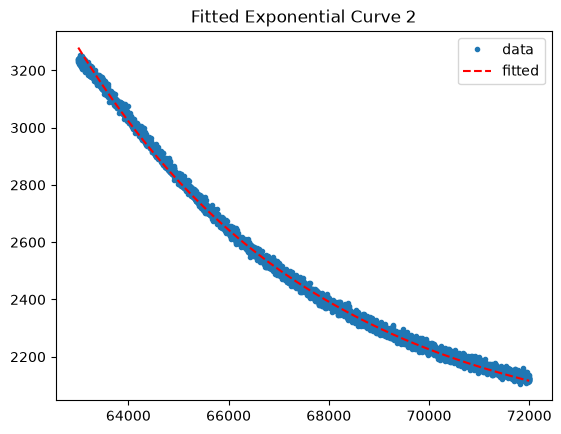

Sensor 3
from_index = 62000, to_index = 72000
R² = 0.999540451483432
t = 0.00039902025499942434


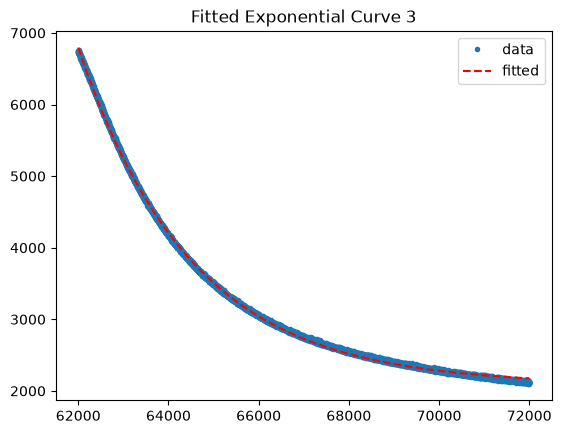

Sensor 4
from_index = 62000, to_index = 72000
R² = 0.9995968270542569
t = 0.00038932630033189727


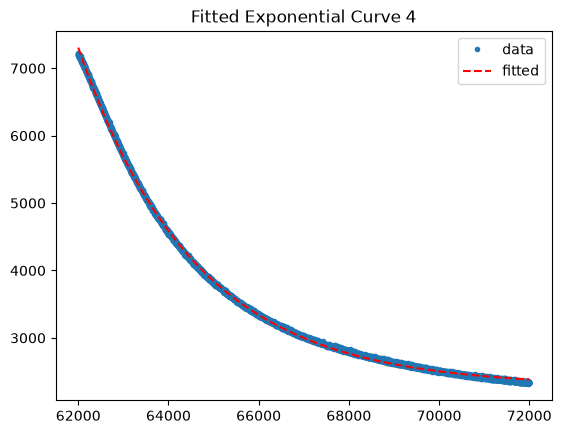

Sensor 5
from_index = 62000, to_index = 72000
R² = 0.9985395028711861
t = 0.0004548672757653817


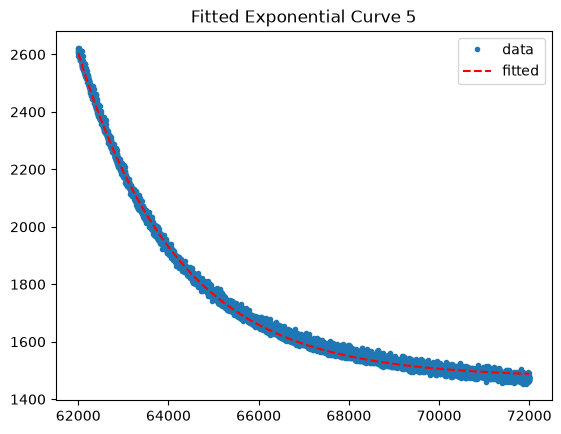

Sensor 6
from_index = 62000, to_index = 72000
R² = 0.9982601398591212
t = 0.0005107881855162426


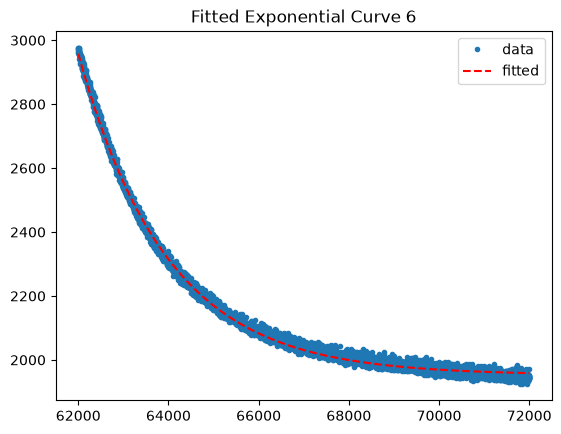

Sensor 7
from_index = 62000, to_index = 72000
R² = 0.9987578644649653
t = 0.0004848671747277892


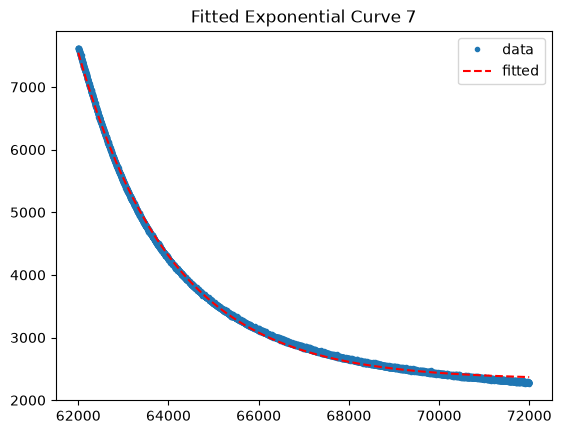

Sensor 8
from_index = 62000, to_index = 72000
R² = 0.9986184919009347
t = 0.0004818866609818322


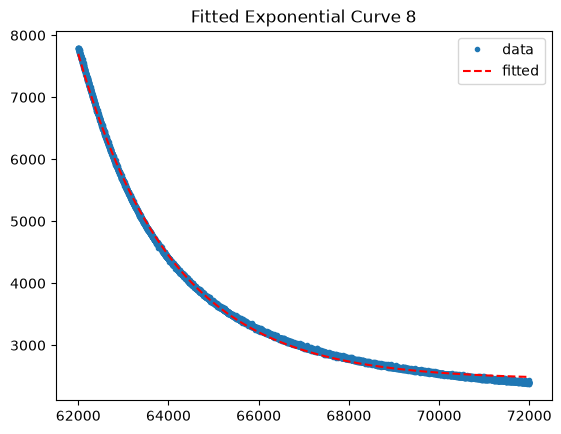

Sensor 9
from_index = 62000, to_index = 72000
R² = 0.6099124653035601
t = 0.0001889677191014843


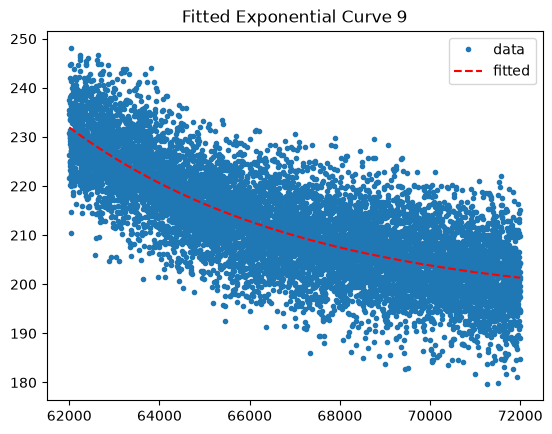

Sensor 10
from_index = 62000, to_index = 72000
R² = 0.9147900220706923
t = 0.00011347116771916138


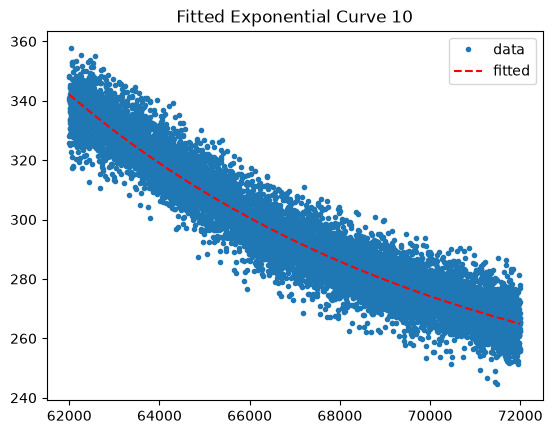

Sensor 11
from_index = 62000, to_index = 72000
R² = 0.9996216572291903
t = 0.00035647174771562615


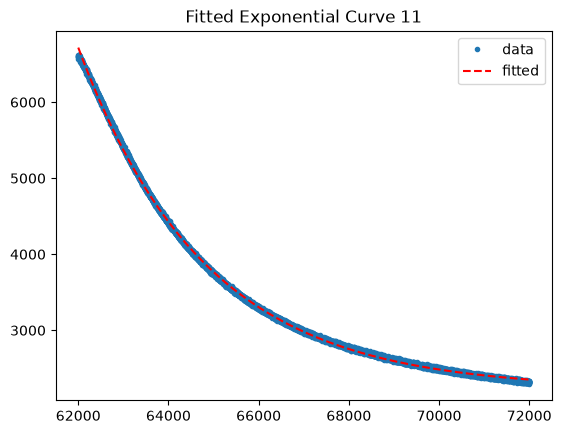

Sensor 12
from_index = 62000, to_index = 72000
R² = 0.9996291164715323
t = 0.00037866363516333485


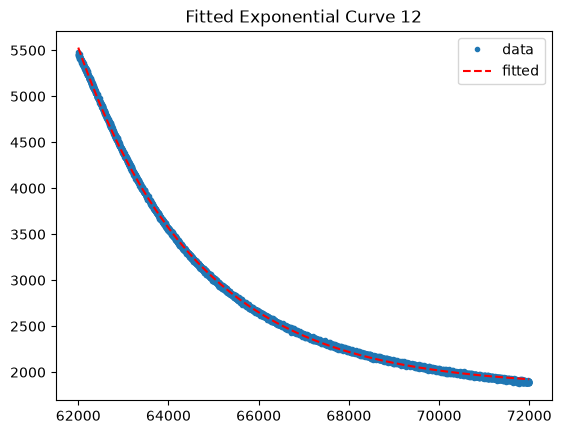

Sensor 13
from_index = 62000, to_index = 72000
R² = 0.9903604606440292
t = 0.0003780163500211117


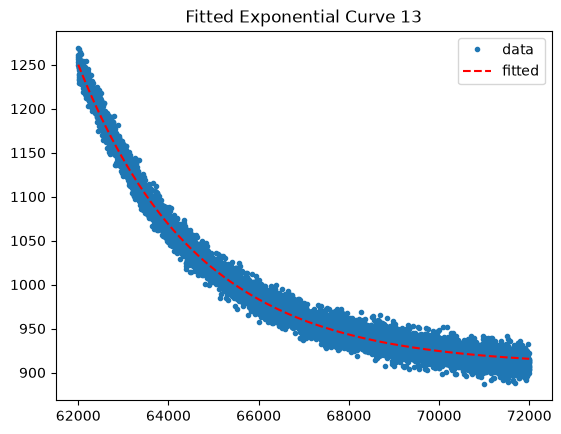

Sensor 14
from_index = 62000, to_index = 72000
R² = 0.9925113539495259
t = 0.00038008647203834203


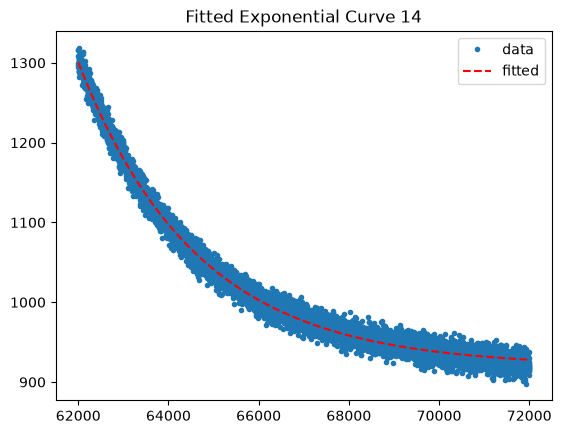

Sensor 15
from_index = 62000, to_index = 72000
R² = 0.9987962247931974
t = 0.0004281642377899276


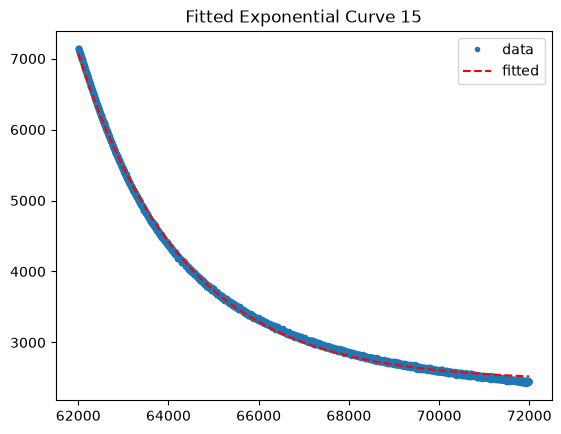

Sensor 16
from_index = 62000, to_index = 72000
R² = 0.9988497933433812
t = 0.00045198176349845387


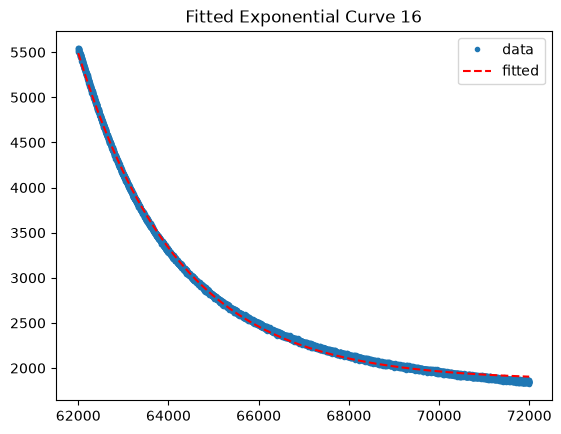

In [79]:
fitting_results = []

for i in range(3, 19):
    sensor_number = i - 2

    from_index = from_indexes[sensor_number + 1]
    to_index = to_indexes[sensor_number + 1]

    xs = ethylene_co.index.to_list()[from_index:to_index]
    xs = np.array(xs)

    ys = ethylene_co.iloc[from_index:to_index, i]
    ys = np.array(ys)

    xs_shifted = xs - xs[0]

    # Автоматически вычисляем подсказку p0
    start_y = ys[0]
    end_y = ys[-1]
    amplitude = end_y - start_y

    # Направление уже правильное: вправо вниз
    estimated_t = 0.001

    p0 = (amplitude, estimated_t, start_y)

    params, cv = scipy.optimize.curve_fit(
        mono_exp,
        xs_shifted,
        ys,
        p0=p0,
        maxfev=20000
    )

    m, t, b = params

    fitted_ys = mono_exp(xs_shifted, m, t, b)

    squaredDiffs = np.square(ys - fitted_ys)
    squaredDiffsFromMean = np.square(ys - np.mean(ys))
    rSquared = 1 - np.sum(squaredDiffs) / np.sum(squaredDiffsFromMean)

    print(f"Sensor {sensor_number}")
    print(f"from_index = {from_index}, to_index = {to_index}")
    print(f"R² = {rSquared}")
    print(f"t = {t}")

    fitting_results.append({
        "sensor_number": sensor_number,
        "from_index": from_index,
        "to_index": to_index,
        "segment_length": to_index - from_index,
        "m": m,
        "t": t,
        "b": b,
        "r2": rSquared
    })

    plt.plot(xs, ys, '.', label="data")
    plt.plot(xs, fitted_ys, '--', label="fitted", color="red")
    plt.title(f"Fitted Exponential Curve {sensor_number}")
    plt.legend()

    plt.savefig(
        f"exponential_fitting_graphs/"
        f'{"normalized/" if normalized else ""}'
        f"exponential_fitting_graph_sensor{sensor_number}_descend.png",
        dpi=300
    )

    plt.show()

df_results = pd.DataFrame(fitting_results)

df_results.to_csv(
    f'fitting_parameters_results_descend{"_normalized" if normalized else ""}.csv',
    index=False
)